<a href="https://colab.research.google.com/github/Nyevuu2/Mkulima-Smart/blob/main/Weather_risk_advisory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This brings in the tool needed to connect to your Google account
from google.colab import drive

# This command actually asks for permission to link your Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import requests

# 1. We define the exact GPS coordinates for our three eastern regions
locations = {
    "Machakos": {"lat": -1.5167, "lon": 37.2667},
    "Makueni": {"lat": -1.8000, "lon": 37.6167},
    "Kitui": {"lat": -1.3667, "lon": 38.0167}
}

# 2. Create an empty list to hold the spreadsheets we get for each region
all_weather_data = []

# 3. We loop through each location to ask the API for data
for city, coords in locations.items():
    print(f"Extracting historical weather data for {city}...")

    # This is the exact web address to ask Open-Meteo for daily temp and rain from 2020 to 2023
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={coords['lat']}&longitude={coords['lon']}&start_date=2020-01-01&end_date=2023-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Africa%2FNairobi"

    # Send the messenger to get the data
    response = requests.get(url)
    data = response.json() # Convert the response into readable text (JSON format)

    # Convert that text into a Pandas spreadsheet
    df = pd.DataFrame(data['daily'])

    # Add a column with the city name so we don't mix them up later!
    df['location'] = city

    # Add this city's spreadsheet to our master list
    all_weather_data.append(df)

# 4. Glue all three spreadsheets (Machakos, Makueni, Kitui) together into one massive dataset
final_raw_data = pd.concat(all_weather_data, ignore_index=True)

# 5. Show the first 5 rows to make sure it worked!
print("\nExtraction Complete! Here is a peek at your raw data:")
print(final_raw_data.head())

Extracting historical weather data for Machakos...
Extracting historical weather data for Makueni...
Extracting historical weather data for Kitui...

Extraction Complete! Here is a peek at your raw data:
         time  temperature_2m_max  temperature_2m_min  precipitation_sum  \
0  2020-01-01                23.4                14.4                0.1   
1  2020-01-02                22.4                15.4                2.0   
2  2020-01-03                22.3                15.4                3.0   
3  2020-01-04                22.5                15.4                4.1   
4  2020-01-05                24.0                15.1                1.0   

   location  
0  Machakos  
1  Machakos  
2  Machakos  
3  Machakos  
4  Machakos  


In [ ]:
# 1. Let's count exactly how many days of data we pulled for each region
print("Total rows of data per region:")
print(final_raw_data['location'].value_counts())

print("\n-----------------------------------\n")

# 2. Let's look at the very bottom of the dataset instead of the top
print("The bottom 5 rows of the dataset:")
print(final_raw_data.tail())


Total rows of data per region:
location
Machakos    1461
Makueni     1461
Kitui       1461
Name: count, dtype: int64

-----------------------------------

The bottom 5 rows of the dataset:
            time  temperature_2m_max  temperature_2m_min  precipitation_sum  \
4378  2023-12-27                26.5                18.8                0.4   
4379  2023-12-28                28.5                18.8                1.5   
4380  2023-12-29                27.5                18.9                1.6   
4381  2023-12-30                26.6                18.1                6.7   
4382  2023-12-31                27.4                18.8                0.8   

     location  
4378    Kitui  
4379    Kitui  
4380    Kitui  
4381    Kitui  
4382    Kitui  


In [ ]:
# Define the path where you want to save it in your Google Drive
# You can change "My Drive" to a specific folder name if you created one for the project
save_path = '/content/drive/My Drive/eastern_regions_raw_weather.csv'

# Tell pandas to convert our digital spreadsheet into a physical CSV file
final_raw_data.to_csv(save_path, index=False)

print(f"Success! Raw data securely saved to: {save_path}")

Success! Raw data securely saved to: /content/drive/My Drive/eastern_regions_raw_weather.csv


In [ ]:
import pandas as pd

# This is the path where we saved our raw data
file_path = '/content/drive/My Drive/eastern_regions_raw_weather.csv'

# Read the CSV file back into a Pandas DataFrame
df_clean = pd.read_csv(file_path)

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
# Check for missing values in every column
print("Missing values per column:")
print(df_clean.isnull().sum())


Missing values per column:
time                  0
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
location              0
dtype: int64


In [ ]:
# 1. Rename columns to make them easier to work with
df_clean = df_clean.rename(columns={
    'temperature_2m_max': 'max_temp',
    'temperature_2m_min': 'min_temp',
    'precipitation_sum': 'rainfall'
})

# 2. Handle any potential missing values
# Using "forward fill" (ffill): if a day's data is missing, it copies the weather from the day before.
df_clean = df_clean.ffill()

# 3. Check our work to make sure it looks clean
print("\nCleaned Data Preview:")
print(df_clean.head())


Cleaned Data Preview:
         time  max_temp  min_temp  rainfall  location
0  2020-01-01      23.4      14.4       0.1  Machakos
1  2020-01-02      22.4      15.4       2.0  Machakos
2  2020-01-03      22.3      15.4       3.0  Machakos
3  2020-01-04      22.5      15.4       4.1  Machakos
4  2020-01-05      24.0      15.1       1.0  Machakos


In [ ]:
# Import the specific tool we need for Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the tool
scaler = MinMaxScaler()

# 2. Tell the scaler exactly which columns to squish
# We DO NOT want to scale the 'time' or 'location' columns because they are text/dates!
columns_to_scale = ['max_temp', 'min_temp', 'rainfall']

# 3. Apply the math to those specific columns
# fit_transform learns the min/max values and then converts the numbers
df_clean[columns_to_scale] = scaler.fit_transform(df_clean[columns_to_scale])

# 4. Look at the magic!
print("Data Normalized Successfully! Check out the new 0 to 1 scale:")
print(df_clean.head())

Data Normalized Successfully! Check out the new 0 to 1 scale:
         time  max_temp  min_temp  rainfall  location
0  2020-01-01  0.397351  0.496063  0.001092  Machakos
1  2020-01-02  0.331126  0.574803  0.021834  Machakos
2  2020-01-03  0.324503  0.574803  0.032751  Machakos
3  2020-01-04  0.337748  0.574803  0.044760  Machakos
4  2020-01-05  0.437086  0.551181  0.010917  Machakos


In [ ]:
# Define the path for the final, processed file
# Notice we are naming it 'processed' so we don't overwrite our raw backup!
processed_path = '/content/drive/My Drive/eastern_regions_processed_weather.csv'

# Save the perfectly clean, scaled data
df_clean.to_csv(processed_path, index=False)

print(f"Success! Your final dataset is securely saved to: {processed_path}")

Success! Your final dataset is securely saved to: /content/drive/My Drive/eastern_regions_processed_weather.csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


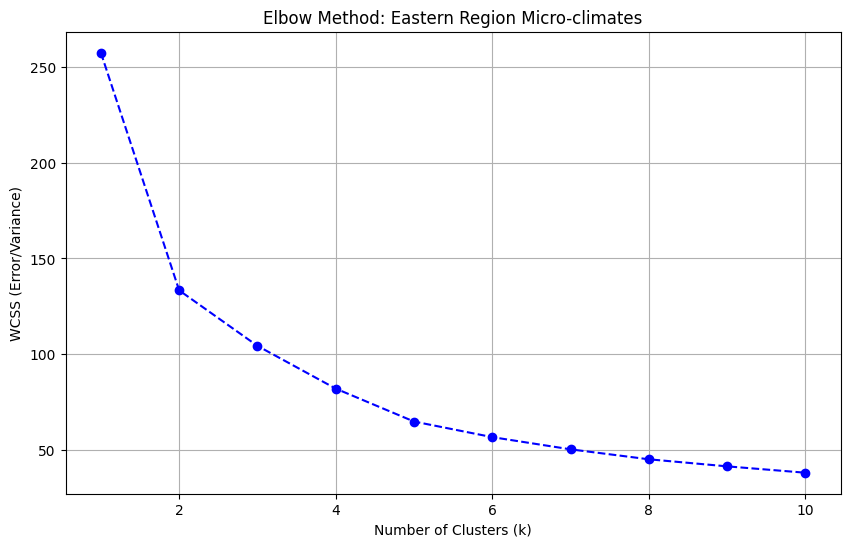

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Mount Google Drive to access the file
drive.mount('/content/drive')

# 2. Load the specific dataset
file_path = '/content/drive/My Drive/eastern_regions_processed_weather.csv'
df_weather = pd.read_csv(file_path)

# 3. Isolate the features for clustering
# K-Means needs pure numbers, so we filter out strings like 'Date' or 'Region' names
df_features = df_weather.select_dtypes(include=['float64', 'int64'])

# 4. Calculate WCSS (Within-Cluster Sum of Squares) for the Elbow Method
wcss = []
for i in range(1, 11):
    # n_init=10 ensures the algorithm runs 10 times with different centroid seeds
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_features)
    wcss.append(kmeans.inertia_)

# 5. Plot the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method: Eastern Region Micro-climates')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Error/Variance)')
plt.grid(True)
plt.show()

In [ ]:
# 1. Initialize the K-Means algorithm with our optimal k=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)

# 2. Train the model and assign a cluster number (0, 1, 2, or 3) to every single row of your weather data
df_weather['Cluster_ID'] = kmeans_final.fit_predict(df_features)

# 3. Extract the Centroids (The average weather conditions for each of the 4 clusters)
centroids = kmeans_final.cluster_centers_

# 4. Create a readable dataframe to view these centroids
# We will match the centroids to your feature column names (Temp, Precip, Humidity)
centroid_df = pd.DataFrame(centroids, columns=df_features.columns)
centroid_df.index.name = 'Cluster_ID'

print("Model successfully trained!")
print("\nHere are the defining characteristics (Centroids) of your 4 Micro-climates:")
print(centroid_df)

# 5. Save the trained model so your PWA can use it later without retraining
import joblib
joblib.dump(kmeans_final, '/content/drive/My Drive/mkulima_kmeans_model.pkl')
print("\nModel saved to Google Drive as 'mkulima_kmeans_model.pkl'")

Model successfully trained!

Here are the defining characteristics (Centroids) of your 4 Micro-climates:
            max_temp  min_temp  rainfall
Cluster_ID                              
0           0.567962  0.759362  0.063089
1           0.299309  0.344019  0.016158
2           0.764849  0.691525  0.010653
3           0.497836  0.523988  0.016682

Model saved to Google Drive as 'mkulima_kmeans_model.pkl'


In [ ]:
import json

def get_agronomic_advisory(cluster_id):
    """
    Traceable Forward-Chaining Inference Engine.
    Maps micro-climate clusters to verified ASAL agronomic protocols.
    """

    knowledge_base = {
        0: { # High Rain, Warm (Optimal)
            "risk_profile": "Optimal Moisture Index",
            "alert_level": "Low Risk - Growth Phase",
            "maize_advisory": "Favorable soil moisture detected. Proceed with nitrogenous top-dressing (CAN) if in vegetative stage (V6-VT). Implement preventative scouting for Fall Armyworm (Spodoptera frugiperda) as high humidity favors egg hatching.",
            "ndengu_advisory": "Optimal vegetative and podding conditions. Maintain weed-free fields to minimize nutrient competition. Monitor for foliar diseases like Powdery Mildew.",
            "agronomic_rationale": "High precipitation + moderate heat creates maximum nutrient uptake capacity but increases pest vector proliferation.",
            "source_citation": "KALRO ASAL Farming Guidelines; Maize AGRIdaksh Pest Management Matrix."
        },
        1: { # Low Temp, Low Rain (Cool/Dry)
            "risk_profile": "Sub-optimal Temperature / Dormancy",
            "alert_level": "Moderate Risk - Stunted Growth",
            "maize_advisory": "Soil temperatures below optimal threshold for rapid cell division. Suspend fertilizer application to prevent leaching or chemical burn. If crop is mature, initiate drying and harvest protocols.",
            "ndengu_advisory": "Metabolic slowdown expected. Avoid chemical interventions. Prepare post-harvest storage treated against bruchids (weevils).",
            "agronomic_rationale": "Low temperatures reduce root permeability and nutrient transport efficiency, rendering fertilizers ineffective.",
            "source_citation": "Adapted from standard Crop Evapotranspiration (ETc) models for semi-arid climates."
        },
        2: { # High Temp, Lowest Rain (Severe Drought)
            "risk_profile": "Critical Heat & Moisture Stress",
            "alert_level": "CRITICAL RISK - Drought Mitigation",
            "maize_advisory": "EMERGENCY: Evapotranspiration exceeds rainfall. Halt all planting. For standing crops, immediately implement moisture conservation (Zai pits, heavy organic mulching). Do not apply inorganic fertilizers.",
            "ndengu_advisory": "Extreme heat may induce flower abortion despite drought tolerance. Avoid field disturbance (weeding) to minimize soil moisture evaporation.",
            "agronomic_rationale": "High temperatures combined with severe moisture deficit trigger stomatal closure, halting photosynthesis and causing thermal stress.",
            "source_citation": "KALRO Drought Mitigation Strategies for Machakos/Makueni/Kitui."
        },
        3: { # Moderate Temp, Low Rain (Mild Stress / Transition)
            "risk_profile": "Mild Moisture Deficit",
            "alert_level": "Elevated Risk - Transition Phase",
            "maize_advisory": "Declining soil moisture profile. Employ conservation agriculture techniques (tie-ridging) to capture any erratic rainfall. Monitor for moisture-stress indicators (leaf rolling).",
            "ndengu_advisory": "Conditions favor rapid pod maturation. Prioritize harvesting mature pods immediately to prevent shattering caused by excessive drying.",
            "agronomic_rationale": "Moderate stress accelerates the reproductive phase (senescence) in legumes to ensure seed production before complete moisture depletion.",
            "source_citation": "KALRO Green Gram (Ndengu) Production Manual for Eastern Kenya."
        }
    }

    if cluster_id in knowledge_base:
        advisory = knowledge_base[cluster_id]

        # Comprehensive JSON Payload
        payload = {
            "status": "success",
            "data": {
                "cluster_id": cluster_id,
                "climate_condition": advisory["risk_profile"],
                "alert_level": advisory["alert_level"],
                "crop_specific_rules": {
                    "Maize": advisory["maize_advisory"],
                    "Ndengu": advisory["ndengu_advisory"]
                },
                "traceability": {
                    "rationale": advisory["agronomic_rationale"],
                    "citation": advisory["source_citation"]
                }
            }
        }
        return json.dumps(payload, indent=4)
    else:
        return json.dumps({"status": "error", "message": "Unknown Cluster ID"})

# Test the upgraded engine
current_weather_cluster = 2
final_output = get_agronomic_advisory(current_weather_cluster)
print(final_output)

{
    "status": "success",
    "data": {
        "cluster_id": 2,
        "climate_condition": "Critical Heat & Moisture Stress",
        "alert_level": "CRITICAL RISK - Drought Mitigation",
        "crop_specific_rules": {
            "Maize": "EMERGENCY: Evapotranspiration exceeds rainfall. Halt all planting. For standing crops, immediately implement moisture conservation (Zai pits, heavy organic mulching). Do not apply inorganic fertilizers.",
            "Ndengu": "Extreme heat may induce flower abortion despite drought tolerance. Avoid field disturbance (weeding) to minimize soil moisture evaporation."
        },
        "traceability": {
            "rationale": "High temperatures combined with severe moisture deficit trigger stomatal closure, halting photosynthesis and causing thermal stress.",
            "citation": "KALRO Drought Mitigation Strategies for Machakos/Makueni/Kitui."
        }
    }
}
